# K-Means Elbow Method Analysis

**Dataset:** `kmeans_elbow.csv`  
**Objective:** Understand how to find the optimal number of clusters using the Elbow Method.

## Tasks
- Run K-Means for **K = 1 to 10**
- Plot **K vs Inertia / WCSS**
- Answer:
  1. Identify the elbow point in the graph
  2. Why does inertia always decrease as K increases?
  3. Is the elbow point clearly visible? What does that imply?


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display all columns
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [2]:
# Load the dataset
data = pd.read_csv("kmeans_elbow.csv")

# Display first 5 rows
data.head()


,Feature1,Feature2
0,-12.039401,11.710508
1,-9.058560,11.069042
2,-9.452685,6.641714
3,7.077678,1.605526
4,6.067105,4.812084


## 3. Basic Dataset Information

In [3]:
print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

print("\nStatistical summary:")
display(data.describe())


Dataset shape: (400, 2)

Column names:
Index(['Feature1', 'Feature2'], dtype='object')

Missing values:
Feature1    0
Feature2    0
dtype: int64

Statistical summary:


,Feature1,Feature2
count,400.000000,400.000000
mean,-3.466780,2.871012
std,5.872422,6.801651
min,-15.580544,-12.634913
25%,-8.172784,-2.070607
50%,-4.688229,4.128116
75%,0.880537,8.294130
max,10.426525,15.814709


## 4. Select Features

K-Means is an unsupervised algorithm, so it does not require a target/class label.

Here, we select all numeric columns from the dataset as input features.


In [5]:
# Select numeric features
X = data.select_dtypes(include=[np.number])

print("Selected features:")
print(X.columns.tolist())

X.head()


Selected features:
['Feature1', 'Feature2']


,Feature1,Feature2
0,-12.039401,11.710508
1,-9.058560,11.069042
2,-9.452685,6.641714
3,7.077678,1.605526
4,6.067105,4.812084


## 5. Standardize the Features

K-Means uses distance calculation. If one feature has a larger scale than another feature, it may dominate the clustering result.

So, we standardize the data using `StandardScaler`.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (400, 2)


## 6. Run K-Means for K = 1 to 10

**Inertia / WCSS** means the sum of squared distances between each point and its assigned cluster centroid.

Lower inertia means points are closer to their centroids.


In [7]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Show inertia values
inertia_table = pd.DataFrame({
    "K": list(k_values),
    "Inertia_WCSS": inertias
})

inertia_table


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

,K,Inertia_WCSS
0,1,800.000000
1,2,465.014306
2,3,176.480817
3,4,110.755336
4,5,98.512658
5,6,87.580534
6,7,77.714283
7,8,66.973807
8,9,59.615408
9,10,52.621454


## 7. Plot K vs Inertia / WCSS

The elbow point is the value of K where the inertia starts decreasing slowly after a sharp drop.


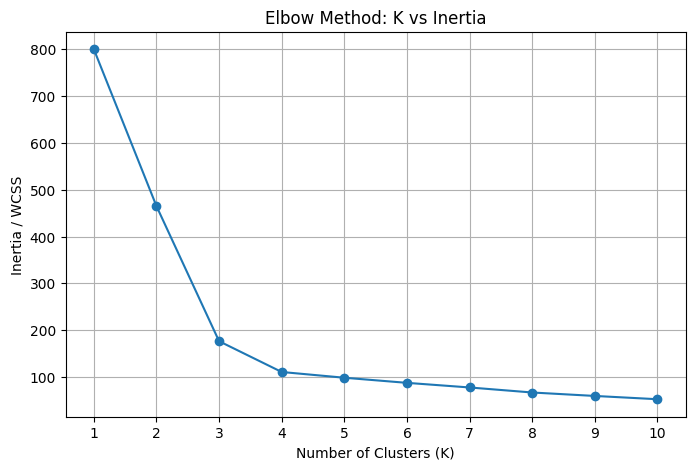

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method: K vs Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()


## 8. Programmatic Elbow Point Estimation

This simple method finds the K value that has the maximum perpendicular distance from the straight line joining the first and last inertia points.

This is only a helper method. The final decision should also use visual interpretation and business/domain understanding.


In [9]:
# Convert K and inertia values into coordinate points
points = np.column_stack((list(k_values), inertias))

first_point = points[0]
last_point = points[-1]

# Direction vector of the line from first point to last point
line_vector = last_point - first_point
line_vector_norm = line_vector / np.linalg.norm(line_vector)

# Calculate perpendicular distance of each point from the line
vectors_from_first = points - first_point
projection_lengths = np.dot(vectors_from_first, line_vector_norm)
projections = np.outer(projection_lengths, line_vector_norm)
distances = np.linalg.norm(vectors_from_first - projections, axis=1)

estimated_elbow_k = list(k_values)[np.argmax(distances)]

print("Estimated elbow point K:", estimated_elbow_k)

elbow_table = pd.DataFrame({
    "K": list(k_values),
    "Inertia_WCSS": inertias,
    "Distance_From_Line": distances
})

elbow_table


Estimated elbow point K: 3


,K,Inertia_WCSS,Distance_From_Line
0,1,800.000000,0.000000e+00
1,2,465.014306,3.033708e+00
2,3,176.480817,5.508075e+00
3,4,110.755336,5.299562e+00
4,5,98.512658,4.447052e+00
5,6,87.580534,3.578760e+00
6,7,77.714283,2.697634e+00
7,8,66.973807,1.827035e+00
8,9,59.615408,9.157118e-01
9,10,52.621454,1.137007e-13


## 9. Plot with Estimated Elbow Point

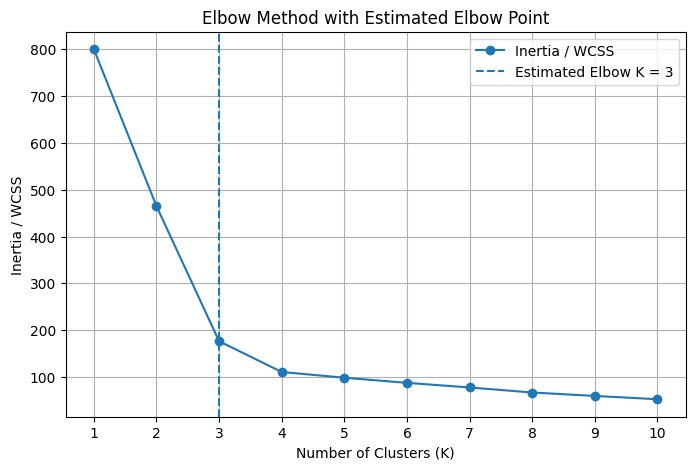

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o", label="Inertia / WCSS")
plt.axvline(x=estimated_elbow_k, linestyle="--", label=f"Estimated Elbow K = {estimated_elbow_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method with Estimated Elbow Point")
plt.xticks(list(k_values))
plt.grid(True)
plt.legend()
plt.show()


## 10. Answers

### Q1. Identify the “elbow point” in the graph

From the inertia values and the elbow graph, the elbow point is around:

**K = 3**

This means the dataset most likely has around **3 meaningful clusters**.

---

### Q2. Why does inertia always decrease as K increases?

Inertia decreases as K increases because more clusters mean more centroids.

When we increase K:
- Each centroid gets fewer nearby points.
- Points become closer to their assigned centroid.
- The total squared distance between points and centroids becomes smaller.

For example:
- With **K = 1**, all points must belong to one cluster, so the distance is high.
- With **K = 3**, points can be divided into three better groups, so distance reduces.
- With **K = 10**, there are more centroids, so distance reduces further.

So inertia will usually keep decreasing as K increases, but after a certain K, the improvement becomes very small.

---

### Q3. Is the elbow point clearly visible? What does that imply?

In this dataset, the elbow is **reasonably visible around K = 3**.

This implies:
- Before K = 3, inertia decreases sharply.
- After K = 3, inertia decreases more slowly.
- Adding more clusters after K = 3 may not give much extra benefit.

So, **K = 3** is a good candidate for the optimal number of clusters.


## 11. Optional: Fit Final K-Means Model Using the Elbow K

In [11]:
final_kmeans = KMeans(n_clusters=estimated_elbow_k, random_state=42, n_init=10)
data["Cluster"] = final_kmeans.fit_predict(X_scaled)

data.head()


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Feature1,Feature2,Cluster
0,-12.039401,11.710508,1
1,-9.058560,11.069042,1
2,-9.452685,6.641714,1
3,7.077678,1.605526,0
4,6.067105,4.812084,0


## 12. Optional: Visualize Final Clusters

This works directly when the dataset has two numeric features.
If your dataset has more than two features, you can use PCA to reduce it to two dimensions for visualization.


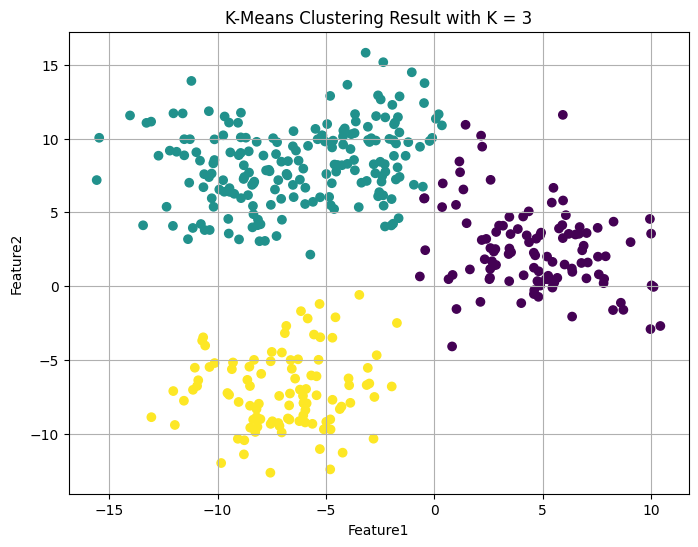

In [12]:
if X.shape[1] == 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=data["Cluster"])
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(f"K-Means Clustering Result with K = {estimated_elbow_k}")
    plt.grid(True)
    plt.show()
else:
    print("Dataset has more than 2 numeric features. Use PCA for 2D visualization.")
